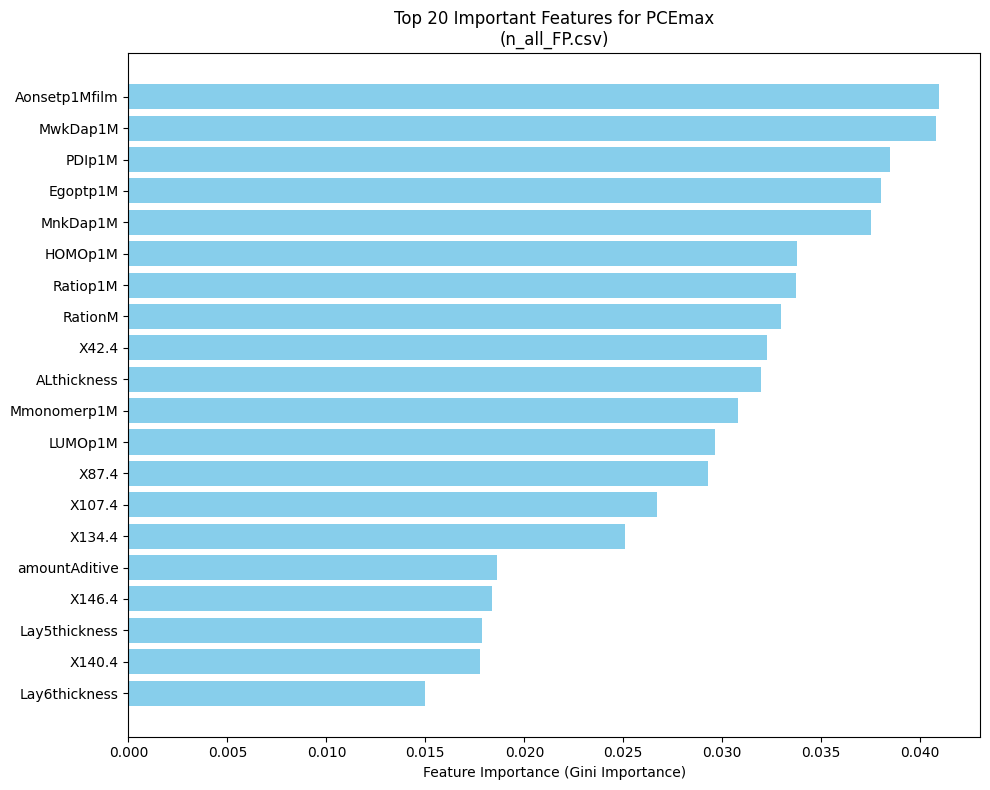

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# --- 設定 ---
base_path = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/"
output_path = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/OOD_check/Rborist/python/importance_plots/"
os.makedirs(output_path, exist_ok=True)

file_name = "n_all_FP.csv"
target_var = "PCEmax"

# 1. データの読み込み
df_raw = pd.read_csv(os.path.join(base_path, file_name), index_col=0).drop(columns=['X'], errors='ignore')
df_temp = df_raw.select_dtypes(include=[np.number]).dropna()
X = df_temp.drop(columns=["Jsc", "Voc", "FF", "PCEmax"], errors='ignore')
y = df_temp[target_var]

# 2. モデル学習
model = RandomForestRegressor(n_estimators=500, max_features=5, min_samples_leaf=1, random_state=42, n_jobs=-1)
model.fit(X, y)

# 3. 特徴量重要度の抽出
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# 4. 可視化 (Bar Plot)
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][::-1], feature_importance_df['Importance'][::-1], color='skyblue')
plt.xlabel('Feature Importance (Gini Importance)')
plt.title(f'Top 20 Important Features for {target_var}\n({file_name})')
plt.tight_layout()
plt.savefig(os.path.join(output_path, f"importance_{file_name}_{target_var}.png"))
plt.show()

/tmp/ipykernel_70651/2273143437.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


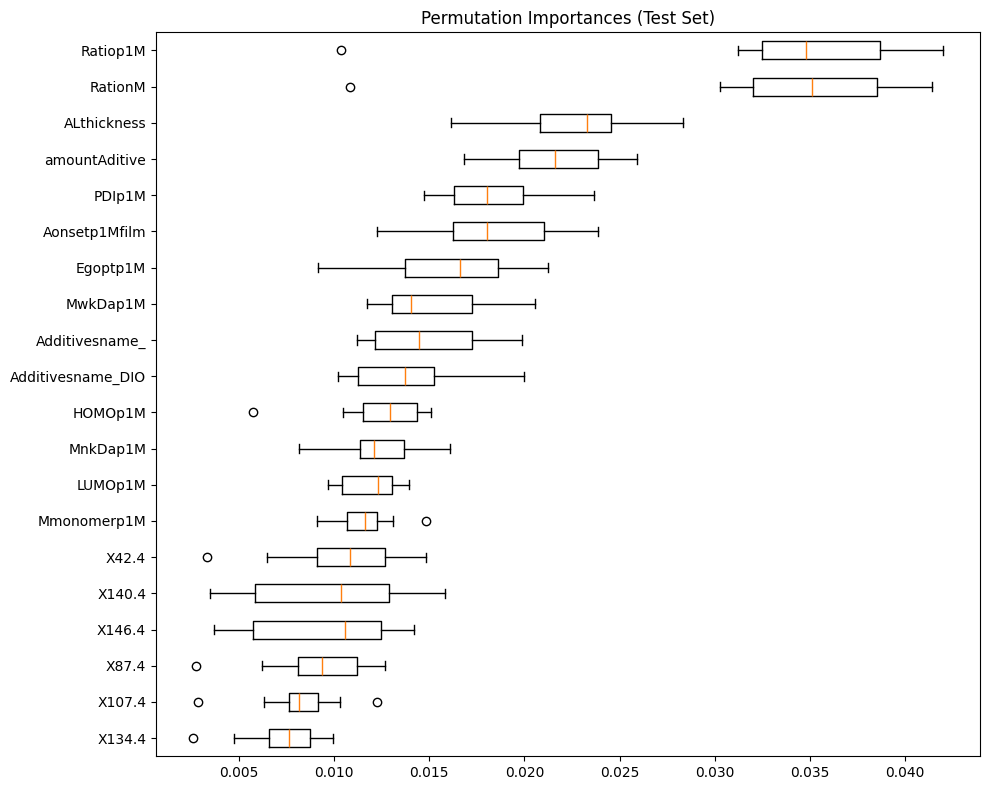

In [3]:
from sklearn.inspection import permutation_importance

# 学習済みモデルに対して計算
result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)

# 結果の可視化
sorted_idx = result.importances_mean.argsort()[-20:] # Top 20
plt.figure(figsize=(10, 8))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Importances (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(output_path, f"permutation_importance_{target_var}.png"))
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- 1. 基本設定 ---
base_path = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/"
mlp_out_dir = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/OOD_check/monmlp/python"
rf_out_dir = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/OOD_check/Rborist/python"

for d in [mlp_out_dir, rf_out_dir]:
    os.makedirs(d, exist_ok=True)

file_names = ["n_base.csv", "n_base_OH.csv", "n_base_FP.csv", "n_all.csv", "n_all_OH.csv", "n_all_FP.csv",
              "m_base.csv", "m_base_OH.csv", "m_base_FP.csv", "m_all.csv", "m_all_OH.csv", "m_all_FP.csv"]
target_vars = ["Jsc", "Voc", "FF", "PCEmax"]
today = datetime.now().strftime("%Y%m%d")

# --- 2. 補助関数の定義 ---
def create_ood_split(df, feature_cols, ood_ratio=0.1):
    X = df[feature_cols].values
    centroid = np.mean(X, axis=0)
    distances = np.linalg.norm(X - centroid, axis=1)
    num_ood = max(1, int(len(df) * ood_ratio))
    ood_indices = np.argsort(distances)[-num_ood:]
    return df.drop(df.index[ood_indices]), df.iloc[ood_indices]

def save_plot_csv(obs, pred, out_path, model_name, file_tag, target_tag, split_type="CV"):
    """グラフ描画用の実測・予測データをCSV保存する関数"""
    df_plot = pd.DataFrame({'Observed': obs, 'Predicted': pred})
    df_plot['Split'] = split_type
    fname = f"plot_data_{model_name}_{file_tag}_{target_tag}_{split_type}.csv"
    df_plot.to_csv(os.path.join(out_path, fname), index=False)

# --- 3. メインループ ---
mlp_summary, rf_summary = [], []

for file in file_names:
    input_path = os.path.join(base_path, file)
    if not os.path.exists(input_path): continue
    print(f"\nProcessing File: {file}")
    
    # データの読み込み（最初の列をindexとし、ID列 X を除外）
    df_raw = pd.read_csv(input_path, index_col=0).drop(columns=['X'], errors='ignore')
    file_tag = file.replace('.csv', '')

    for target in target_vars:
        if target not in df_raw.columns: continue
        
        # 前処理：数値のみ、欠損除去、分散ゼロ変数除去
        df_temp = df_raw.select_dtypes(include=[np.number]).dropna()
        f_cols = [c for c in df_temp.columns if c not in target_vars]
        f_cols = df_temp[f_cols].var()[df_temp[f_cols].var() > 0].index.tolist()
        
        if len(df_temp) < 20 or len(f_cols) == 0: continue

        # OOD分割 (Fingerprintデータのみ)
        is_fp = "_FP.csv" in file
        df_train, df_test = create_ood_split(df_temp, f_cols) if is_fp else (df_temp, None)
        
        # 標準化
        scaler = StandardScaler()
        X_train = scaler.fit_transform(df_train[f_cols])
        y_train = df_train[target]
        
        # --- (A) MLP (monmlp代替) 実行 ---
        mlp = MLPRegressor(max_iter=2000, random_state=42, solver='lbfgs')
        mlp_grid = GridSearchCV(mlp, {'hidden_layer_sizes': [(64,), (128,), (64,32)], 'alpha': [0.001, 0.01]}, 
                                cv=KFold(10, shuffle=True, random_state=42), n_jobs=-1)
        mlp_grid.fit(X_train, y_train)
        
        # MLP結果記録
        y_pred_cv = mlp_grid.predict(X_train)
        save_plot_csv(y_train, y_pred_cv, mlp_out_dir, "MLP", file_tag, target, "CV")
        
        mlp_res = {"File": file, "Target": target, "R2": r2_score(y_train, y_pred_cv), "n_samples": len(df_temp), "n_features": len(f_cols)}
        if df_test is not None:
            y_pred_ood = mlp_grid.predict(scaler.transform(df_test[f_cols]))
            mlp_res["OOD_R2"] = r2_score(df_test[target], y_pred_ood)
            save_plot_csv(df_test[target], y_pred_ood, mlp_out_dir, "MLP", file_tag, target, "OOD")
        mlp_summary.append(mlp_res)

        # --- (B) RF (Rborist代替) 実行 ---
        rf = RandomForestRegressor(n_estimators=500, random_state=42)
        rf_grid = GridSearchCV(rf, {'max_features': [1, 3, 5], 'min_samples_leaf': [1, 3, 5]}, 
                               cv=KFold(10, shuffle=True, random_state=42), n_jobs=-1)
        rf_grid.fit(X_train, y_train)
        
        # RF結果記録
        y_pred_cv_rf = rf_grid.predict(X_train)
        save_plot_csv(y_train, y_pred_cv_rf, rf_out_dir, "RF", file_tag, target, "CV")
        
        rf_res = {"File": file, "Target": target, "R2": r2_score(y_train, y_pred_cv_rf), "n_samples": len(df_temp), "n_features": len(f_cols)}
        if df_test is not None:
            y_pred_ood_rf = rf_grid.predict(scaler.transform(df_test[f_cols]))
            rf_res["OOD_R2"] = r2_score(df_test[target], y_pred_ood_rf)
            save_plot_csv(df_test[target], y_pred_ood_rf, rf_out_dir, "RF", file_tag, target, "OOD")
        rf_summary.append(rf_res)

# --- 4. サマリーCSVの保存 ---
pd.DataFrame(mlp_summary).to_csv(os.path.join(mlp_out_dir, f"summary_MLP_{today}.csv"), index=False)
pd.DataFrame(rf_summary).to_csv(os.path.join(rf_out_dir, f"summary_RF_{today}.csv"), index=False)

print(f"\n✅ すべての解析が完了しました。")
print(f"MLP出力先: {mlp_out_dir}")
print(f"RF出力先: {rf_out_dir}")


Processing File: n_base.csv


/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma

/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma

/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma


Processing File: n_base_OH.csv


...


Processing File: m_base_OH.csv


/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma

/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma

/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma

/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/is/i-yasuaki/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma